In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

load_dotenv()

engine = create_engine(
    f"postgresql://{os.getenv('DB_USERNAME')}:{os.getenv('DB_PASSWORD')}@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (10, 6)

print("Ready")

Ready


In [3]:
df = pd.read_csv('../datasets/pdm_survey005.csv')

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nFirst few rows:")
print(df.head())
print("\nData types:")
print(df.info())

Shape: (20, 22)

Columns:
['_id', 'start', 'end', 'beneficiary_id', 'enumerator', 'province', 'district', 'gender', 'age', 'received_food', 'quantity_correct', 'food_quality', 'distribution_point_distance', 'waiting_time_hours', 'dignity_respected', 'complaints_mechanism_known', 'would_recommend', 'primary_use_of_food', 'challenges', 'overall_satisfaction', 'gps_latitude', 'gps_longitude']

First few rows:
   _id             start               end  beneficiary_id    enumerator  \
0    1  2024-02-15 09:00  2024-02-15 09:25               1  Enumerator_A   
1    2  2024-02-15 09:30  2024-02-15 09:55               2  Enumerator_A   
2    3  2024-02-15 10:00  2024-02-15 10:30               3  Enumerator_B   
3    4  2024-02-15 10:35  2024-02-15 11:00               4  Enumerator_B   
4    5  2024-02-15 11:00  2024-02-15 11:30               5  Enumerator_A   

   province  district  gender  age received_food  ...  \
0     Kabul     Kabul    Male   45           yes  ...   
1     Kabul     Kab

In [4]:
df_clean = df.copy()

# Fixing dates
df_clean['start'] = pd.to_datetime(df_clean['start'])
df_clean['end'] = pd.to_datetime(df_clean['end'])

In [5]:
# Calculating survey duration in minutes
df_clean['duration_minutes'] = (
    (df_clean['end'] - df_clean['start']).dt.total_seconds() / 60
).round(1)

In [6]:
# Droping _id
df_clean = df_clean.drop(columns=['_id'])

In [7]:
print("Cleaning done")
print(df_clean.dtypes)
print("\nSurvey duration stats:")
print(df_clean['duration_minutes'].describe())

Cleaning done
start                          datetime64[us]
end                            datetime64[us]
beneficiary_id                          int64
enumerator                                str
province                                  str
district                                  str
gender                                    str
age                                     int64
received_food                             str
quantity_correct                          str
food_quality                              str
distribution_point_distance             int64
waiting_time_hours                    float64
dignity_respected                         str
complaints_mechanism_known                str
would_recommend                           str
primary_use_of_food                       str
challenges                                str
overall_satisfaction                    int64
gps_latitude                          float64
gps_longitude                         float64
duration_minutes    

In [8]:
# Duration by enumerator
print(df_clean.groupby('enumerator')['duration_minutes'].describe().round(1))

              count  mean  std   min   25%   50%   75%   max
enumerator                                                  
Enumerator_A    8.0  26.2  2.3  25.0  25.0  25.0  26.2  30.0
Enumerator_B    7.0  27.1  2.7  25.0  25.0  25.0  30.0  30.0
Enumerator_C    5.0  29.0  2.2  25.0  30.0  30.0  30.0  30.0


In [10]:
# Frequency analysis —>  what percentage said yes/no to each question
# Yes/No columns
yn_columns = ['received_food', 'quantity_correct', 'dignity_respected', 
              'complaints_mechanism_known', 'would_recommend']

# Calculating percentage yes for each
print("-- Yes/No Question Results --")
for col in yn_columns:
    yes_pct = (df_clean[col] == 'yes').sum() / len(df_clean) * 100
    print(f"{col}: {yes_pct:.1f}% yes") #:.1f calculate a float to 1 decimal

-- Yes/No Question Results --
received_food: 100.0% yes
quantity_correct: 80.0% yes
dignity_respected: 80.0% yes
complaints_mechanism_known: 60.0% yes
would_recommend: 80.0% yes


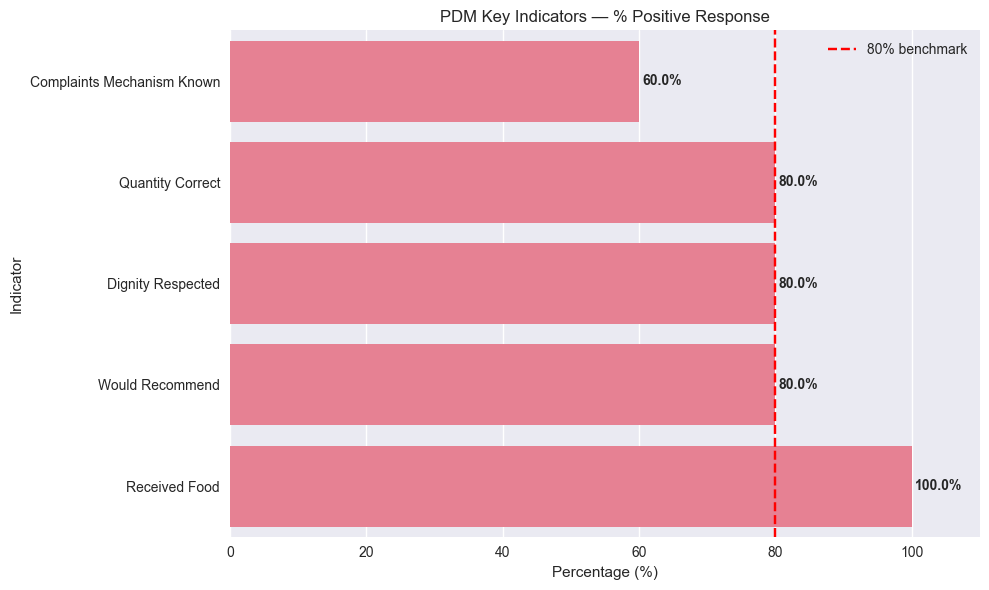

In [11]:
# Calculating all percentages
yn_results = {}
for col in yn_columns:
    yn_results[col] = (df_clean[col] == 'yes').sum() / len(df_clean) * 100

# Converting to dataframe for plotting
yn_df = pd.DataFrame(list(yn_results.items()), columns=['indicator', 'percentage'])
yn_df = yn_df.sort_values('percentage')

# Cleaning up indicator names for display
yn_df['indicator'] = yn_df['indicator'].str.replace('_', ' ').str.title()

plt.figure()
ax = sns.barplot(data=yn_df, x='percentage', y='indicator')

# Adding percentage labels
for i, v in enumerate(yn_df['percentage']):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontweight='bold')

# Adding benchmark line at 80%
plt.axvline(x=80, color='red', linestyle='--', label='80% benchmark')
plt.legend()
plt.title('PDM Key Indicators — % Positive Response')
plt.xlabel('Percentage (%)')
plt.ylabel('Indicator')
plt.xlim(0, 110)
plt.tight_layout()
plt.show()

In [12]:
#  Satisfaction analysis —> rating scale questions
# Overall satisfaction distribution
print("-- Satisfaction Score Distribution --")
print(df_clean['overall_satisfaction'].value_counts().sort_index())
print(f"\nMean satisfaction: {df_clean['overall_satisfaction'].mean():.2f}")
print(f"Median satisfaction: {df_clean['overall_satisfaction'].median():.1f}")


-- Satisfaction Score Distribution --
overall_satisfaction
2    4
3    3
4    8
5    5
Name: count, dtype: int64

Mean satisfaction: 3.70
Median satisfaction: 4.0


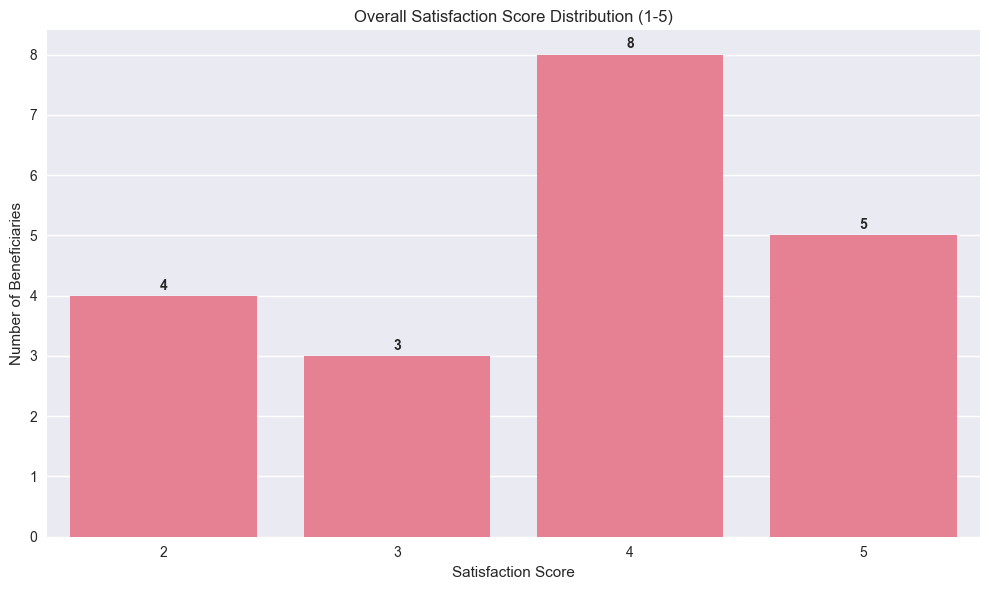

In [13]:
# Visualize
plt.figure()
satisfaction_counts = df_clean['overall_satisfaction'].value_counts().sort_index()
ax = sns.barplot(x=satisfaction_counts.index, y=satisfaction_counts.values)

for i, v in enumerate(satisfaction_counts.values):
    ax.text(i, v + 0.1, str(v), ha='center', fontweight='bold')

plt.title('Overall Satisfaction Score Distribution (1-5)')
plt.xlabel('Satisfaction Score')
plt.ylabel('Number of Beneficiaries')
plt.tight_layout()
plt.show()

In [ ]:

# Satisfaction by province
# value_counts() sorts by count (highest first) by default. 
# sort_index() sorts by the index values instead of the counts.
print("\n-- Mean Satisfaction by Province --")
print(df_clean.groupby('province')['overall_satisfaction'].mean().round(2).sort_values())


=== Mean Satisfaction by Province ===
province
Kandahar    3.14
Balkh       4.00
Herat       4.00
Kabul       4.00
Name: overall_satisfaction, dtype: float64
